In [ ]:
!pip install xgboost

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving EDA_Notebook_Balaji.ipynb to EDA_Notebook_Balaji (1).ipynb


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

In [ ]:
df = pd.read_csv("Balaji Fast Food Sales.csv")

df.head()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            1000 non-null   int64 
 1   date                1000 non-null   object
 2   item_name           1000 non-null   object
 3   item_type           1000 non-null   object
 4   item_price          1000 non-null   int64 
 5   quantity            1000 non-null   int64 
 6   transaction_amount  1000 non-null   int64 
 7   transaction_type    893 non-null    object
 8   received_by         1000 non-null   object
 9   time_of_sale        1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [ ]:
df.columns

Index(['order_id', 'date', 'item_name', 'item_type', 'item_price', 'quantity',
       'transaction_amount', 'transaction_type', 'received_by',
       'time_of_sale'],
      dtype='object')

In [ ]:
df.head(10)

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening
5,6,11/14/2022,Vadapav,Fastfood,20,10,200,Cash,Mr.,Evening
6,7,05-03-2022,Sugarcane juice,Beverages,25,9,225,Cash,Mr.,Evening
7,8,12/22/2022,Panipuri,Fastfood,20,14,280,Online,Mr.,Night
8,9,06-10-2022,Panipuri,Fastfood,20,1,20,Cash,Mrs.,Morning
9,10,9/16/2022,Panipuri,Fastfood,20,5,100,Online,Mr.,Afternoon


In [ ]:
df.describe()

,order_id,item_price,quantity,transaction_amount
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,33.315000,8.162000,275.230000
std,288.819436,14.921744,4.413075,204.402979
min,1.000000,20.000000,1.000000,20.000000
25%,250.750000,20.000000,4.000000,120.000000
50%,500.500000,25.000000,8.000000,240.000000
75%,750.250000,50.000000,12.000000,360.000000
max,1000.000000,60.000000,15.000000,900.000000


In [ ]:
df.isnull().sum()

,0
order_id,0
date,0
item_name,0
item_type,0
item_price,0
quantity,0
transaction_amount,0
transaction_type,107
received_by,0
time_of_sale,0


In [ ]:
df = df.dropna()

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.head()

,order_id,item_price,quantity,transaction_amount,date_01-02-2023,date_01-03-2023,date_01-04-2023,date_01-05-2023,date_01-06-2023,date_01-07-2023,...,item_name_Sandwich,item_name_Sugarcane juice,item_name_Vadapav,item_type_Fastfood,transaction_type_Online,received_by_Mrs.,time_of_sale_Evening,time_of_sale_Midnight,time_of_sale_Morning,time_of_sale_Night
1,2,20,15,300,False,False,False,False,False,False,...,False,False,True,True,False,False,False,False,False,False
2,3,20,1,20,False,False,False,False,False,False,...,False,False,True,True,False,False,False,False,False,False
3,4,25,6,150,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,True
4,5,25,8,200,False,False,False,False,False,False,...,False,True,False,False,True,False,True,False,False,False
5,6,20,10,200,False,False,False,False,False,False,...,False,False,True,True,False,False,True,False,False,False


In [ ]:
df.columns

Index(['order_id', 'item_price', 'quantity', 'transaction_amount',
       'date_01-02-2023', 'date_01-03-2023', 'date_01-04-2023',
       'date_01-05-2023', 'date_01-06-2023', 'date_01-07-2023',
       ...
       'item_name_Sandwich', 'item_name_Sugarcane juice', 'item_name_Vadapav',
       'item_type_Fastfood', 'transaction_type_Online', 'received_by_Mrs.',
       'time_of_sale_Evening', 'time_of_sale_Midnight', 'time_of_sale_Morning',
       'time_of_sale_Night'],
      dtype='object', length=355)

In [ ]:
y = df["quantity"]

In [ ]:
X = df.drop(["quantity","order_id","transaction_amount"], axis=1)

In [ ]:
train_size = int(len(df)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [ ]:
print(X_train.shape)
print(X_test.shape)


(714, 352)
(179, 352)


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 5.028830616036302
Linear Regression RMSE: 6.151378862979832


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 4.008405959031657
Random Forest RMSE: 4.745016198931166


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor()

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [ ]:
mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 4.025394916534424
XGBoost RMSE: 4.728275007753905


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model":["Linear Regression","Random Forest","XGBoost"],
    "MAE":[mae_lr, mae_rf, mae_xgb],
    "RMSE":[rmse_lr, rmse_rf, rmse_xgb]
})

results

,Model,MAE,RMSE
0,Linear Regression,5.028831,6.151379
1,Random Forest,4.008406,4.745016
2,XGBoost,4.025395,4.728275


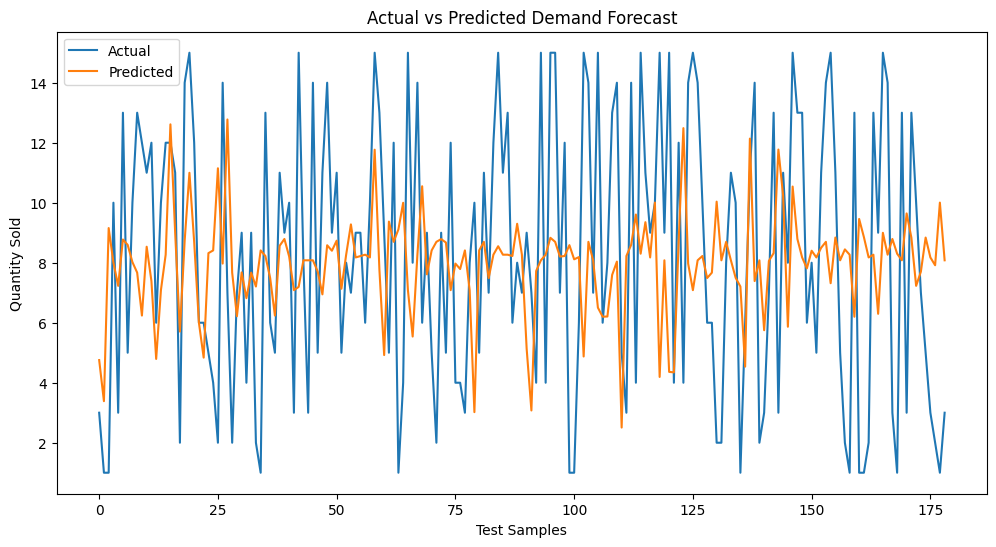

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")
plt.plot(pred_xgb, label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Demand Forecast")

plt.xlabel("Test Samples")
plt.ylabel("Quantity Sold")

plt.show()

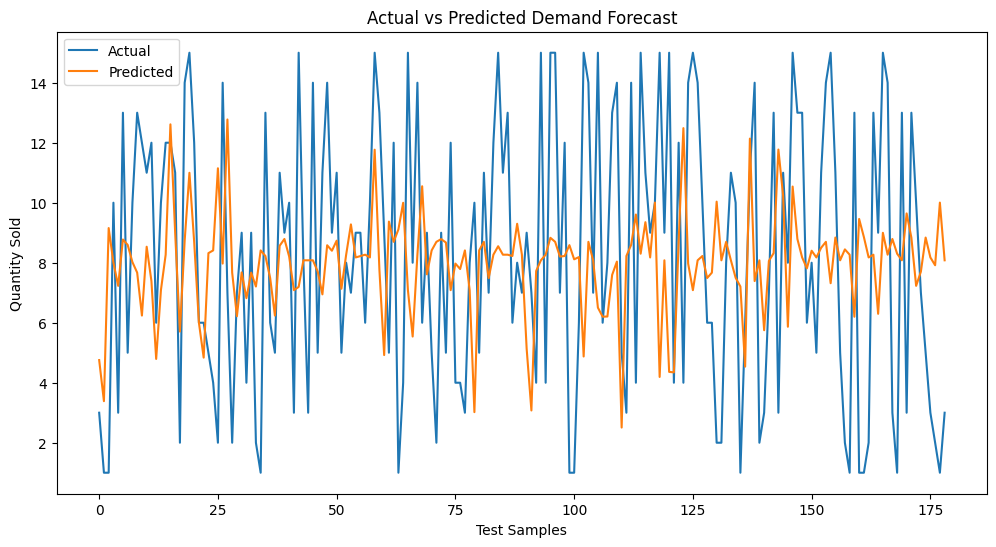

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")
plt.plot(pred_xgb, label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Demand Forecast")

plt.xlabel("Test Samples")
plt.ylabel("Quantity Sold")

plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.1]
}

grid = GridSearchCV(
    XGBRegressor(),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error'
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

pred_tuned = best_model.predict(X_test)

In [ ]:
mae_tuned = mean_absolute_error(y_test, pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, pred_tuned))

print("Tuned XGBoost MAE:", mae_tuned)
print("Tuned XGBoost RMSE:", rmse_tuned)

Tuned XGBoost MAE: 3.9056034088134766
Tuned XGBoost RMSE: 4.4677534792928535


In [ ]:
grid.best_params_

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}